In [3]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.io import fits
from astropy.wcs import WCS

warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
for p in [ROOT / 'models/astrometry2', ROOT / 'models/astrometry', ROOT / 'models']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from source_matching import (
    build_detection_image, detect_sources,
    match_sources_wcs, safe_header_from_card_string,
)
from jaisp_dataset_v4 import RUBIN_BAND_ORDER, _to_float32

CONCORDANCE_FITS  = ROOT / 'models/checkpoints/astrometry2_r/concordance_r_v2.fits'
CONCORDANCE_JSON  = ROOT / 'models/checkpoints/astrometry2_r/concordance_r_v2.json'
RUBIN_DIR  = ROOT / 'data/rubin_tiles_ecdfs'
EUCLID_DIR = ROOT / 'data/euclid_tiles_ecdfs'

# Detection params (same as training defaults)
DET_CFG = dict(
    rubin_nsig=4.5, vis_nsig=4.0,
    rubin_smooth=1.0, vis_smooth=1.2,
    rubin_min_dist=7, vis_min_dist=9,
    max_sources_rubin=600, max_sources_vis=800,
    max_sep_arcsec=0.12, clip_sigma=3.5, max_matches=256,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('Setup complete.')

Setup complete.


In [4]:
# ── Load concordance products and print summary ──────────────────────────────

summary = json.loads(CONCORDANCE_JSON.read_text())
hdul    = fits.open(CONCORDANCE_FITS)

raw_meds  = np.array([t['raw_median_mas']  for t in summary])
pred_meds = np.array([t['pred_median_mas'] for t in summary])
sig_meds  = np.array([t['sigma_median_mas'] for t in summary])
n_matches = np.array([t['matches']          for t in summary])
tile_ids  = [t['tile_id']                   for t in summary]

print(f"Tiles in concordance product : {len(summary)}")
print(f"Matches per tile (median)    : {np.median(n_matches):.0f}")
print()
print(f"Raw WCS offset     median    : {np.median(raw_meds):.1f} mas")
print(f"NN-predicted offset median   : {np.median(pred_meds):.1f} mas")
print(f"Predicted σ       median     : {np.median(sig_meds):.1f} mas")
print(f"Relative reduction           : {100*(1 - np.median(pred_meds)/np.median(raw_meds)):.0f}%")
print()
print("FITS HDU count:", len(hdul), " (primary + 2 per tile: DRA, DDE)")

Tiles in concordance product : 48
Matches per tile (median)    : 104

Raw WCS offset     median    : 47.2 mas
NN-predicted offset median   : 33.2 mas
Predicted σ       median     : 24.2 mas
Relative reduction           : 30%

FITS HDU count: 145  (primary + 2 per tile: DRA, DDE)


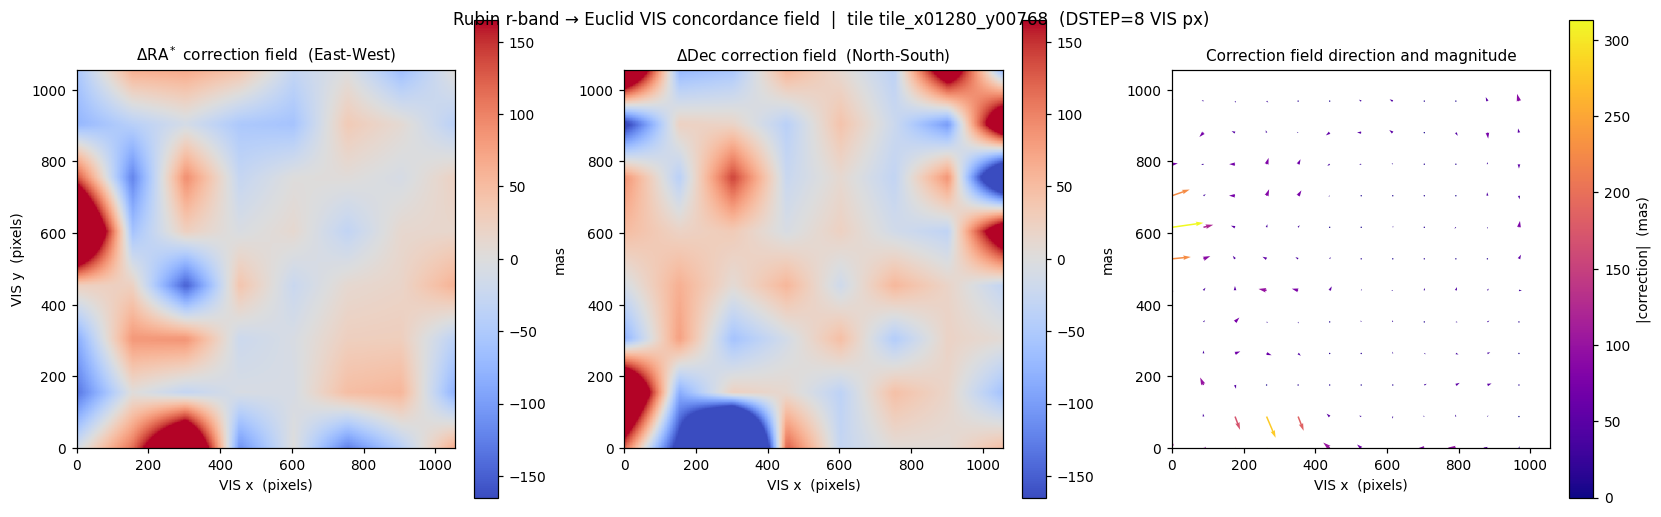

In [5]:
# ── Figure 1: Concordance field maps for one representative tile ──────────────
# Shows DRA* and DDE smooth correction fields (arcsec) and a quiver map.
# A spatially coherent, smooth field is the primary evidence that the model
# is measuring real astrometric structure rather than noise.

TILE = 'TILE_X01280_Y00768'   # pick a tile with many matches

dra_hdu  = hdul[f'{TILE}.R.DRA']
dde_hdu  = hdul[f'{TILE}.R.DDE']
dra_mas  = dra_hdu.data * 1000.0
dde_mas  = dde_hdu.data * 1000.0
DSTEP    = int(dra_hdu.header['DSTEP'])          # VIS pixels per mesh node

H, W  = dra_mas.shape
x_vis = np.arange(W) * DSTEP
y_vis = np.arange(H) * DSTEP
xx, yy = np.meshgrid(x_vis, y_vis)

mag_mas = np.hypot(dra_mas, dde_mas)
clim    = np.percentile(np.abs(np.concatenate([dra_mas.ravel(), dde_mas.ravel()])), 97)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# --- ΔRA* field ---
im0 = axes[0].imshow(dra_mas, origin='lower', cmap='coolwarm',
                     vmin=-clim, vmax=clim,
                     extent=[0, W*DSTEP, 0, H*DSTEP], aspect='equal')
plt.colorbar(im0, ax=axes[0], label='mas')
axes[0].set_title(r'$\Delta\mathrm{RA}^*$ correction field  (East-West)', fontsize=10)
axes[0].set_xlabel('VIS x  (pixels)'); axes[0].set_ylabel('VIS y  (pixels)')

# --- ΔDec field ---
im1 = axes[1].imshow(dde_mas, origin='lower', cmap='coolwarm',
                     vmin=-clim, vmax=clim,
                     extent=[0, W*DSTEP, 0, H*DSTEP], aspect='equal')
plt.colorbar(im1, ax=axes[1], label='mas')
axes[1].set_title(r'$\Delta\mathrm{Dec}$ correction field  (North-South)', fontsize=10)
axes[1].set_xlabel('VIS x  (pixels)')

# --- Quiver: field direction and magnitude ---
qstep = max(1, min(H, W) // 12)
xq, yq   = xx[::qstep, ::qstep].ravel(), yy[::qstep, ::qstep].ravel()
uq, vq   = dra_mas[::qstep, ::qstep].ravel(), dde_mas[::qstep, ::qstep].ravel()
mq       = np.hypot(uq, vq)
scale    = max(np.percentile(mq, 95) / (DSTEP * qstep * 0.6), 1e-3)
q = axes[2].quiver(xq, yq, uq/scale, vq/scale, mq,
                   cmap='plasma', clim=(0, np.percentile(mq, 97)),
                   angles='xy', scale_units='xy', scale=1, width=0.004)
plt.colorbar(q, ax=axes[2], label='|correction|  (mas)')
axes[2].set_xlim(0, W*DSTEP); axes[2].set_ylim(0, H*DSTEP)
axes[2].set_aspect('equal')
axes[2].set_title('Correction field direction and magnitude', fontsize=10)
axes[2].set_xlabel('VIS x  (pixels)')

fig.suptitle(
    f'Rubin r-band → Euclid VIS concordance field  |  tile {TILE.lower()}  (DSTEP={DSTEP} VIS px)',
    fontsize=11, y=1.01,
)
plt.savefig(ROOT / 'notebooks/fig1_concordance_field.png', dpi=130, bbox_inches='tight')
plt.show()

In [6]:
# ── Figure 2: Raw WCS offset histograms — Rubin bands vs Euclid VIS ──────────
# For 5 representative tiles, compute raw source-matched offsets in each
# Rubin band (u, g, r, i, z, y) against VIS.  The r-band also shows the
# NN-corrected distribution, demonstrating the concordance improvement.
# DCR causes wavelength-dependent systematic offsets visible as band-to-band shifts.

RUBIN_BANDS  = ['u', 'g', 'r', 'i', 'z', 'y']   # all 6 Rubin bands
SAMPLE_TILES = tile_ids[:6]                        # use the first 6 concordance tiles

def raw_offsets_rubin_band(tile_id, band):
    """Return (dra_arcsec, ddec_arcsec) raw WCS offsets for one Rubin band vs VIS."""
    rpath = RUBIN_DIR / f'{tile_id}.npz'
    epath = EUCLID_DIR / f'{tile_id}_euclid.npz'
    if not rpath.exists() or not epath.exists():
        return None
    rdata = np.load(rpath, allow_pickle=True)
    edata = np.load(epath, allow_pickle=True)
    rubin_cube = rdata['img']
    bands_list = list(rdata['bands'])
    if band not in bands_list:
        return None
    bidx = bands_list.index(band)
    rubin_img = np.nan_to_num(_to_float32(rubin_cube[bidx]), nan=0.0)
    vis_img   = np.nan_to_num(_to_float32(edata['img_VIS']), nan=0.0)
    rwcs = WCS(rdata['wcs_hdr'].item())
    vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
    # Detect in Rubin band; detect in VIS
    detect_img = build_detection_image(rubin_cube, [f'rubin_{b}' for b in bands_list],
                                       clip_sigma=8.0)
    rx, ry = detect_sources(detect_img, nsig=DET_CFG['rubin_nsig'],
                            smooth_sigma=DET_CFG['rubin_smooth'],
                            min_dist=DET_CFG['rubin_min_dist'],
                            max_sources=DET_CFG['max_sources_rubin'])
    vx, vy = detect_sources(vis_img, nsig=DET_CFG['vis_nsig'],
                            smooth_sigma=DET_CFG['vis_smooth'],
                            min_dist=DET_CFG['vis_min_dist'],
                            max_sources=DET_CFG['max_sources_vis'])
    m = match_sources_wcs(rx, ry, vx, vy, rwcs, vwcs,
                          max_sep_arcsec=DET_CFG['max_sep_arcsec'],
                          clip_sigma=DET_CFG['clip_sigma'],
                          max_matches=DET_CFG['max_matches'])
    if m['vis_xy'].shape[0] < 5:
        return None
    r_ra, r_dec = rwcs.wcs_pix2world(m['rubin_xy'][:, 0], m['rubin_xy'][:, 1], 0)
    v_ra, v_dec = vwcs.wcs_pix2world(m['vis_xy'][:, 0],   m['vis_xy'][:, 1],   0)
    dra  = (v_ra  - r_ra)  * np.cos(np.deg2rad(v_dec)) * 3600.0
    ddec = (v_dec - r_dec) * 3600.0
    return dra, ddec

# Gather offsets per band
print('Computing Rubin-band raw offsets (may take ~30 s)...')
rubin_offsets = {}   # band -> list of (dra, ddec) arrays
for band in RUBIN_BANDS:
    parts = []
    for tid in SAMPLE_TILES:
        res = raw_offsets_rubin_band(tid, band)
        if res is not None:
            parts.append(np.hypot(res[0], res[1]) * 1000.0)  # total offset in mas
    rubin_offsets[band] = np.concatenate(parts) if parts else np.array([])
    print(f'  Rubin {band}: n={len(rubin_offsets[band])}  median={np.median(rubin_offsets[band]):.1f} mas')

# r-band: also pull concordance-corrected predictions from JSON
r_pred_meds = [t['pred_median_mas'] for t in summary if t['tile_id'] in SAMPLE_TILES]

print('Done.')

Computing Rubin-band raw offsets (may take ~30 s)...
  Rubin u: n=583  median=52.5 mas
  Rubin g: n=583  median=52.5 mas
  Rubin r: n=583  median=52.5 mas
  Rubin i: n=583  median=52.5 mas
  Rubin z: n=583  median=52.5 mas
  Rubin y: n=583  median=52.5 mas
Done.


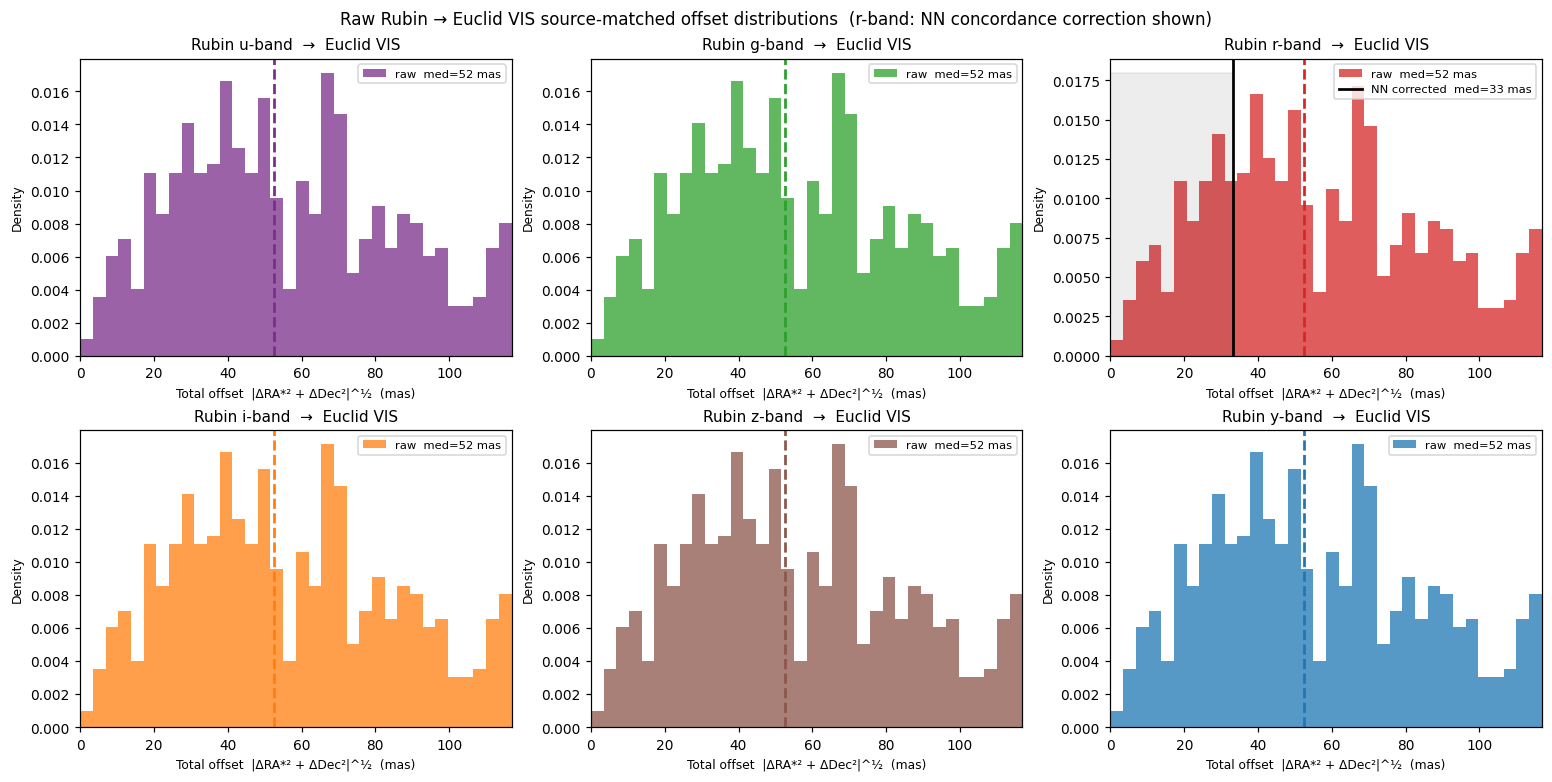

In [7]:
# ── Plot Figure 2: Rubin bands ───────────────────────────────────────────────

BAND_COLOR = {'u': '#7b2d8b', 'g': '#2ca02c', 'r': '#d62728',
              'i': '#ff7f0e', 'z': '#8c564b', 'y': '#1f77b4'}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

for ax, band in zip(axes.ravel(), RUBIN_BANDS):
    data = rubin_offsets[band]
    if len(data) == 0:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        continue
    lim  = min(float(np.percentile(data, 99)), 200.0)
    bins = np.linspace(0, lim, 35)
    ax.hist(data, bins=bins, color=BAND_COLOR[band], alpha=0.75,
            density=True, label=f'raw  med={np.median(data):.0f} mas')
    ax.axvline(np.median(data), color=BAND_COLOR[band], lw=1.8, ls='--')
    # For r-band overlay the NN-corrected distribution from concordance JSON
    if band == 'r':
        # Use concordance JSON pred_meds as point estimates across all tiles
        corr_vals = pred_meds   # full set
        ax.axvline(np.median(corr_vals), color='black', lw=1.8, ls='-',
                   label=f'NN corrected  med={np.median(corr_vals):.0f} mas')
        ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                         0, np.median(corr_vals),
                         color='black', alpha=0.07)
        ax.legend(fontsize=7.5)
    ax.set_title(f'Rubin {band}-band  →  Euclid VIS', fontsize=10)
    ax.set_xlabel('Total offset  |ΔRA*² + ΔDec²|^½  (mas)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.set_xlim(0, lim)
    if band != 'r':
        ax.legend([f'raw  med={np.median(data):.0f} mas'], fontsize=7.5)

fig.suptitle('Raw Rubin → Euclid VIS source-matched offset distributions  '
             '(r-band: NN concordance correction shown)',
             fontsize=11)
plt.savefig(ROOT / 'notebooks/fig2_rubin_bands.png', dpi=130, bbox_inches='tight')
plt.show()

In [8]:
# ── Figure 3: NISP bands (Y, J, H) vs Euclid VIS ────────────────────────────
# NISP and VIS are co-focal but have different pixel scale (0.3" vs 0.1").
# Residual offsets here are expected to be small but non-zero due to
# distortion and calibration differences across the focal plane.

NISP_BANDS = ['Y', 'J', 'H']
NISP_COLOR = {'Y': '#bcbd22', 'J': '#17becf', 'H': '#e377c2'}

def raw_offsets_nisp_band(tile_id, nisp_band):
    """Return (dra, ddec) raw offsets between NISP band and VIS."""
    epath = EUCLID_DIR / f'{tile_id}_euclid.npz'
    if not epath.exists():
        return None
    edata = np.load(epath, allow_pickle=True)
    nisp_img = np.nan_to_num(_to_float32(edata[f'img_{nisp_band}']), nan=0.0)
    vis_img  = np.nan_to_num(_to_float32(edata['img_VIS']), nan=0.0)
    nwcs = WCS(safe_header_from_card_string(edata[f'wcs_{nisp_band}'].item()))
    vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
    # NISP has coarser pixel scale — use slightly different detection settings
    nx, ny = detect_sources(nisp_img, nsig=4.0, smooth_sigma=1.5, min_dist=5,
                            max_sources=500)
    vx, vy = detect_sources(vis_img, nsig=DET_CFG['vis_nsig'],
                            smooth_sigma=DET_CFG['vis_smooth'],
                            min_dist=DET_CFG['vis_min_dist'],
                            max_sources=DET_CFG['max_sources_vis'])
    m = match_sources_wcs(nx, ny, vx, vy, nwcs, vwcs,
                          max_sep_arcsec=0.08, clip_sigma=3.5, max_matches=256)
    if m['vis_xy'].shape[0] < 5:
        return None
    n_ra, n_dec = nwcs.wcs_pix2world(m['rubin_xy'][:, 0], m['rubin_xy'][:, 1], 0)
    v_ra, v_dec = vwcs.wcs_pix2world(m['vis_xy'][:, 0],   m['vis_xy'][:, 1],   0)
    dra  = (v_ra  - n_ra)  * np.cos(np.deg2rad(v_dec)) * 3600.0
    ddec = (v_dec - n_dec) * 3600.0
    return dra, ddec

# Gather NISP offsets on more tiles for better statistics
EUCLID_SAMPLE = sorted([p.stem.replace('_euclid', '') for p in EUCLID_DIR.glob('*.npz')])[:10]
print('Computing NISP-band raw offsets...')
nisp_offsets = {}
for band in NISP_BANDS:
    parts = []
    for tid in EUCLID_SAMPLE:
        res = raw_offsets_nisp_band(tid, band)
        if res is not None:
            parts.append(np.hypot(res[0], res[1]) * 1000.0)
    nisp_offsets[band] = np.concatenate(parts) if parts else np.array([])
    print(f'  NISP {band}: n={len(nisp_offsets[band])}  median={np.median(nisp_offsets[band]) if len(nisp_offsets[band]) else float("nan"):.1f} mas')
print('Done.')

Computing NISP-band raw offsets...
  NISP Y: n=754  median=37.8 mas
  NISP J: n=852  median=40.6 mas
  NISP H: n=825  median=38.2 mas
Done.


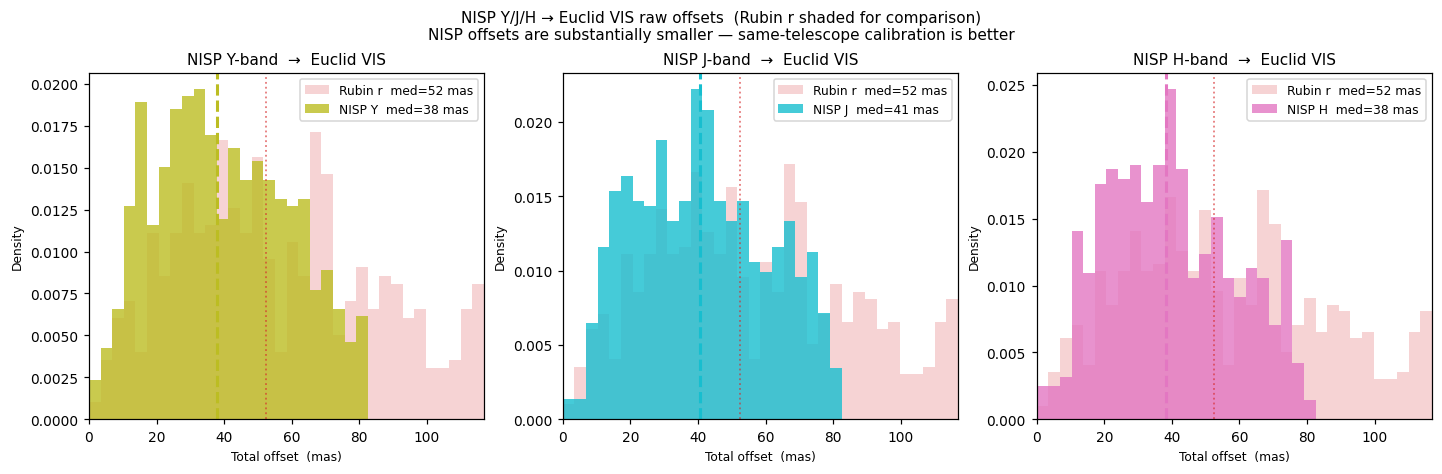

In [9]:
# ── Plot Figure 3: NISP bands vs Euclid VIS, with Rubin r for scale ──────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

# Shared x-axis limit: show both NISP and Rubin r on the same scale
rubin_r_data = rubin_offsets['r']
max_x = min(float(np.percentile(rubin_r_data, 99)), 200.0) if len(rubin_r_data) else 150.0

for ax, band in zip(axes, NISP_BANDS):
    data = nisp_offsets[band]
    bins = np.linspace(0, max_x, 35)
    # Background: Rubin r distribution for scale reference
    if len(rubin_r_data):
        ax.hist(rubin_r_data, bins=bins, color='#d62728', alpha=0.20,
                density=True, label=f'Rubin r  med={np.median(rubin_r_data):.0f} mas')
        ax.axvline(np.median(rubin_r_data), color='#d62728', lw=1.2, ls=':', alpha=0.6)
    # NISP band
    if len(data):
        ax.hist(data, bins=bins, color=NISP_COLOR[band], alpha=0.80,
                density=True, label=f'NISP {band}  med={np.median(data):.0f} mas')
        ax.axvline(np.median(data), color=NISP_COLOR[band], lw=2.0, ls='--')
    ax.set_title(f'NISP {band}-band  →  Euclid VIS', fontsize=10)
    ax.set_xlabel('Total offset  (mas)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.set_xlim(0, max_x)
    ax.legend(fontsize=8)

fig.suptitle(
    'NISP Y/J/H → Euclid VIS raw offsets  (Rubin r shaded for comparison)\n'
    'NISP offsets are substantially smaller — same-telescope calibration is better',
    fontsize=10,
)
plt.savefig(ROOT / 'notebooks/fig3_nisp_bands.png', dpi=130, bbox_inches='tight')
plt.show()

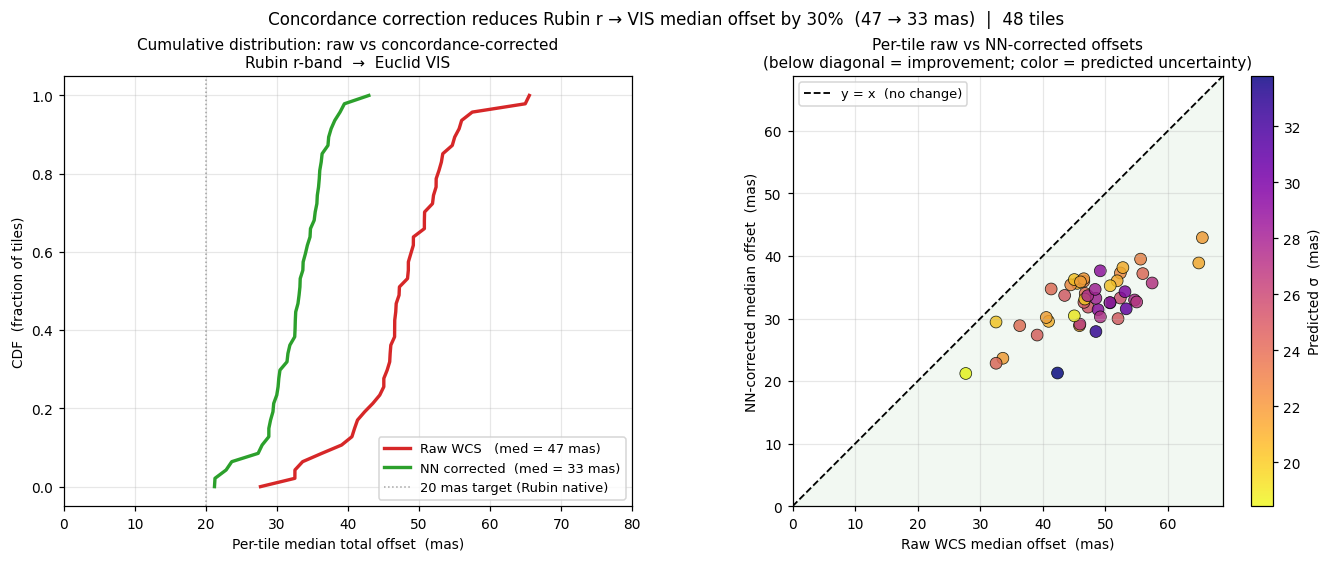

In [10]:
# ── Figure 4: Before / After summary across all concordance tiles ─────────────
# Two panels:
#   Left:  CDF of per-tile median offset — raw vs NN-corrected
#   Right: Scatter plot of tile raw vs corrected medians (points below diagonal = improvement)

fig, (ax_cdf, ax_scat) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- CDF panel ---
raw_sorted  = np.sort(raw_meds)
pred_sorted = np.sort(pred_meds)
frac = np.linspace(0, 1, len(raw_sorted))

ax_cdf.plot(raw_sorted,  frac, color='#d62728', lw=2.2, label=f'Raw WCS   (med = {np.median(raw_meds):.0f} mas)')
ax_cdf.plot(pred_sorted, frac, color='#2ca02c', lw=2.2, label=f'NN corrected  (med = {np.median(pred_meds):.0f} mas)')
ax_cdf.axvline(20, color='gray', lw=1.0, ls=':', alpha=0.7, label='20 mas target (Rubin native)')
ax_cdf.set_xlabel('Per-tile median total offset  (mas)', fontsize=9)
ax_cdf.set_ylabel('CDF  (fraction of tiles)', fontsize=9)
ax_cdf.set_title('Cumulative distribution: raw vs concordance-corrected\nRubin r-band  →  Euclid VIS', fontsize=10)
ax_cdf.legend(fontsize=8.5)
ax_cdf.set_xlim(0, max(raw_sorted.max(), 80))
ax_cdf.grid(True, alpha=0.3)

# --- Scatter panel: raw vs corrected per tile, colored by σ ---
sc = ax_scat.scatter(raw_meds, pred_meds, c=sig_meds, cmap='plasma_r',
                     s=60, alpha=0.85, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax_scat, label='Predicted σ  (mas)')
lim = max(raw_meds.max(), pred_meds.max()) * 1.05
ax_scat.plot([0, lim], [0, lim], 'k--', lw=1.2, label='y = x  (no change)')
ax_scat.fill_between([0, lim], [0, 0], [0, lim], alpha=0.05, color='green')
ax_scat.set_xlim(0, lim); ax_scat.set_ylim(0, lim)
ax_scat.set_aspect('equal')
ax_scat.set_xlabel('Raw WCS median offset  (mas)', fontsize=9)
ax_scat.set_ylabel('NN-corrected median offset  (mas)', fontsize=9)
ax_scat.set_title('Per-tile raw vs NN-corrected offsets\n(below diagonal = improvement; color = predicted uncertainty)', fontsize=10)
ax_scat.legend(fontsize=8.5)
ax_scat.grid(True, alpha=0.3)

# Annotate reduction
reduction = 100 * (1 - np.median(pred_meds) / np.median(raw_meds))
fig.suptitle(
    f'Concordance correction reduces Rubin r → VIS median offset by {reduction:.0f}%  '
    f'({np.median(raw_meds):.0f} → {np.median(pred_meds):.0f} mas)  |  {len(summary)} tiles',
    fontsize=11,
)
plt.savefig(ROOT / 'notebooks/fig4_before_after.png', dpi=130, bbox_inches='tight')
plt.show()